# Hidden Semi-Markov Model regimes

- same 5 features and 0.8/0.2 split as the hmm notebook, directly comparable
- HSMM models each regime's spell LENGTH with an explicit duration distribution (zero-diagonal transition matrix, staying is handled by durations)
- optimizes state count and covariance type on train, evaluates with the held-out score, then refits the final spec
- concepts explained in hsmm_explained.md
- install once if needed: python -m pip install gaussian-hsmm==0.1.0

In [1]:
from gaussian_hsmm import GaussianHSMM
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
#nelson siegel factors
ns = pd.read_csv("../data/ns.csv")
ns.rename(columns={"Beta 1": "level", "Beta 2": "slope", "Beta 3": "curvature"}, inplace=True)
ns["Date"] = pd.to_datetime(ns["Date"])
ns.set_index("Date", inplace=True)

#5 year breakeven inflation
BE5 = pd.read_csv("../data/T5YIE.csv").dropna()
BE5.rename(columns={"observation_date": "Date", "T5YIE": "BE5"}, inplace=True)
BE5["Date"] = pd.to_datetime(BE5["Date"])
BE5.set_index("Date", inplace=True)

#effective federal funds rate
EFFR = pd.read_csv("../data/EFFR.csv").dropna()
EFFR.rename(columns={"observation_date": "Date"}, inplace=True)
EFFR["Date"] = pd.to_datetime(EFFR["Date"])
EFFR.set_index("Date", inplace=True)

#2 year yield for the policy spread
df = pd.read_csv("../data/FRB_H15.csv").dropna()
df.rename(columns={"Series Description": "Date", "Market yield on U.S. Treasury securities at 2-year  constant maturity, quoted on investment basis": "2Y"}, inplace=True)
df["Date"] = pd.to_datetime(df["Date"])
df.set_index("Date", inplace=True)

rates = df[["2Y"]].merge(EFFR[["EFFR"]], left_index=True, right_index=True, how="left")
rates = rates.apply(pd.to_numeric, errors="coerce")
rates["policy_spread"] = rates["2Y"] - rates["EFFR"]

features = ["level", "slope", "curvature", "BE5", "policy_spread"]

combined = ns.merge(BE5[["BE5"]], left_index=True, right_index=True, how="left")
combined = combined.merge(rates[["policy_spread"]], left_index=True, right_index=True, how="left")
combined = combined[features].apply(pd.to_numeric, errors="coerce").dropna().sort_index()

#chronological 80/20 split
split = int(0.8 * len(combined))
trainDf = combined.iloc[:split]
testDf = combined.iloc[split:]

#scaler fit only on training data
scaler = StandardScaler()
xTrain = scaler.fit_transform(trainDf[features])
xTest = scaler.transform(testDf[features])

print("train: ", trainDf.index.min().date(), " to ", trainDf.index.max().date(), " (", len(trainDf), ")")
print("test:  ", testDf.index.min().date(), " to ", testDf.index.max().date(), " (", len(testDf), ")")

train:  2003-01-02  to  2021-09-08  ( 4672 )
test:   2021-09-09  to  2026-05-14  ( 1169 )


#### Parameter optimization

- grid: 2 to 4 states, diag and full covariance, max_duration 126
- tuning fits use 2 duration-EM iterations for speed (final spec refit properly below)
- table reports train log likelihood, held-out log likelihood per observation, AIC, BIC
- prints the BIC pick and the held-out pick

In [3]:
tuningRows = []

for covarianceType in ["diag", "full"]:
    for nStates in range(2, 5):
        try:
            candidate = GaussianHSMM(
                n_components = nStates,
                covariance_type = covarianceType,
                max_duration = 126,
                n_iter = 2,
                hmm_n_iter = 300,
                tol = 1e-3,
                min_covar = 1e-4,
                random_state = 42,
            )
            candidate.fit(xTrain)

            tuningRows.append([
                nStates,
                covarianceType,
                candidate.score(xTrain),
                candidate.score(xTest) / len(xTest),
                candidate.aic(xTrain),
                candidate.bic(xTrain),
            ])
        except (ValueError, np.linalg.LinAlgError):
            print("fit failed for ", nStates, " states ", covarianceType)

tuning = pd.DataFrame(tuningRows, columns=["nStates", "covarianceType", "trainLogLikelihood", "testLogLikelihoodPerObs", "aic", "bic"])
print(tuning.sort_values("bic").to_string(index=False))

bestBic = tuning.loc[tuning["bic"].idxmin()]
bestHeldOut = tuning.loc[tuning["testLogLikelihoodPerObs"].idxmax()]
print("\nBIC choice: ", int(bestBic["nStates"]), " states ", bestBic["covarianceType"])
print("held-out choice: ", int(bestHeldOut["nStates"]), " states ", bestHeldOut["covarianceType"])

Model is not converging.  Current: -4355.323449748597 is not greater than -4355.32061069643. Delta is -0.00283905216747371


 nStates covarianceType  trainLogLikelihood  testLogLikelihoodPerObs          aic          bic
       4           full        -6565.253409                -9.786294 13320.506817 13933.194357
       3           full        -7916.364413               -11.068624 15968.728827 16407.284119
       2           full       -16915.908810                -8.759942 33917.817621 34195.139349
       4           diag       -18222.148904               -13.464367 36554.297807 36909.011646
       3           diag       -21937.014474               -13.599929 43950.028949 44195.103965
       2           diag       -26945.984002               -14.056955 53937.968005 54086.302883

BIC choice:  4  states  full
held-out choice:  2  states  full


#### Final model (3 states, diag, 6 duration-EM iterations)

- state means and standard deviations converted back to original units
- transition matrix = where a spell goes AFTER it ends (zero diagonal by design)
- duration_means_ = learned average spell length per state, warns if any mean nears the 126 day cap

In [4]:
finalStates = 3
model = GaussianHSMM(
    n_components = finalStates,
    covariance_type = "diag",
    max_duration = 126,
    n_iter = 6,
    hmm_n_iter = 500,
    tol = 1e-3,
    min_covar = 1e-4,
    random_state = 42,
)
model.fit(xTrain)

#state means back in original units
stateMeans = pd.DataFrame(scaler.inverse_transform(model.means_), columns=features)
stateMeans.index.name = "state"
print("state means (original units):")
print(stateMeans.round(3).to_string())

#within state volatility
stateStd = pd.DataFrame(np.sqrt(np.asarray(model.covars_) * (scaler.scale_ ** 2)), columns=features)
stateStd.index.name = "state"
print("\nstate standard deviations:")
print(stateStd.round(3).to_string())

#transitions after a spell ends (zero diagonal is intentional)
transitionMatrix = pd.DataFrame(
    model.transmat_,
    index = ["from_state_" + str(i) for i in range(finalStates)],
    columns = ["to_state_" + str(i) for i in range(finalStates)],
)
print("\ntransition probabilities after a spell ends:")
print(transitionMatrix.round(4).to_string())

print("\nExplicit duration means in trading days")
for i in range(finalStates):
    print(" Expected duration of state " + str(i) + ": " + str(round(model.duration_means_[i], 1)))

if np.any(model.duration_means_ > 0.75 * model.max_duration):
    print("WARNING: a duration mean is near max_duration, raise the cap and refit")

state means (original units):
       level  slope  curvature    BE5  policy_spread
state                                               
0     -3.938  4.374     20.188  1.647          0.754
1      4.198 -2.282      0.930  1.934         -0.123
2     -0.440  1.324     11.008  1.868          0.438

state standard deviations:
       level  slope  curvature    BE5  policy_spread
state                                               
0      1.537  1.512      4.524  0.772          0.309
1      1.811  1.502      4.308  0.444          0.409
2      1.287  1.316      3.957  0.440          0.243

transition probabilities after a spell ends:
              to_state_0  to_state_1  to_state_2
from_state_0      0.0000      0.0000         1.0
from_state_1      0.0000      0.0000         1.0
from_state_2      0.5289      0.4711         0.0

Explicit duration means in trading days
 Expected duration of state 0: 50.0
 Expected duration of state 1: 84.6
 Expected duration of state 2: 42.7


#### Decoded regimes

- decodes the full-sample regime path (retrospective) and lists the longest spells
- compares decoded spell lengths per state against the fitted duration means
- plots the regime path and smoothed probabilities with the train/test split marked
- note: the forecasting notebooks do not use these smoothed outputs, they run a causal forward filter instead

longest decoded spells:
 state      start        end  tradingDays
     1 2019-05-09 2019-11-06          126
     1 2025-07-16 2026-01-15          126
     1 2024-04-23 2024-10-22          126
     1 2023-10-19 2024-04-19          126
     2 2018-05-29 2018-11-27          126
     2 2017-02-06 2017-08-04          126
     0 2008-09-15 2009-03-17          125
     1 2022-10-21 2023-04-20          124
     1 2006-10-16 2007-04-12          122
     1 2023-04-24 2023-10-17          122

average decoded spell length per state (compare with duration means above):
       count  mean  max
state                  
0         24  56.2  125
1         28  92.0  126
2         52  36.9  126


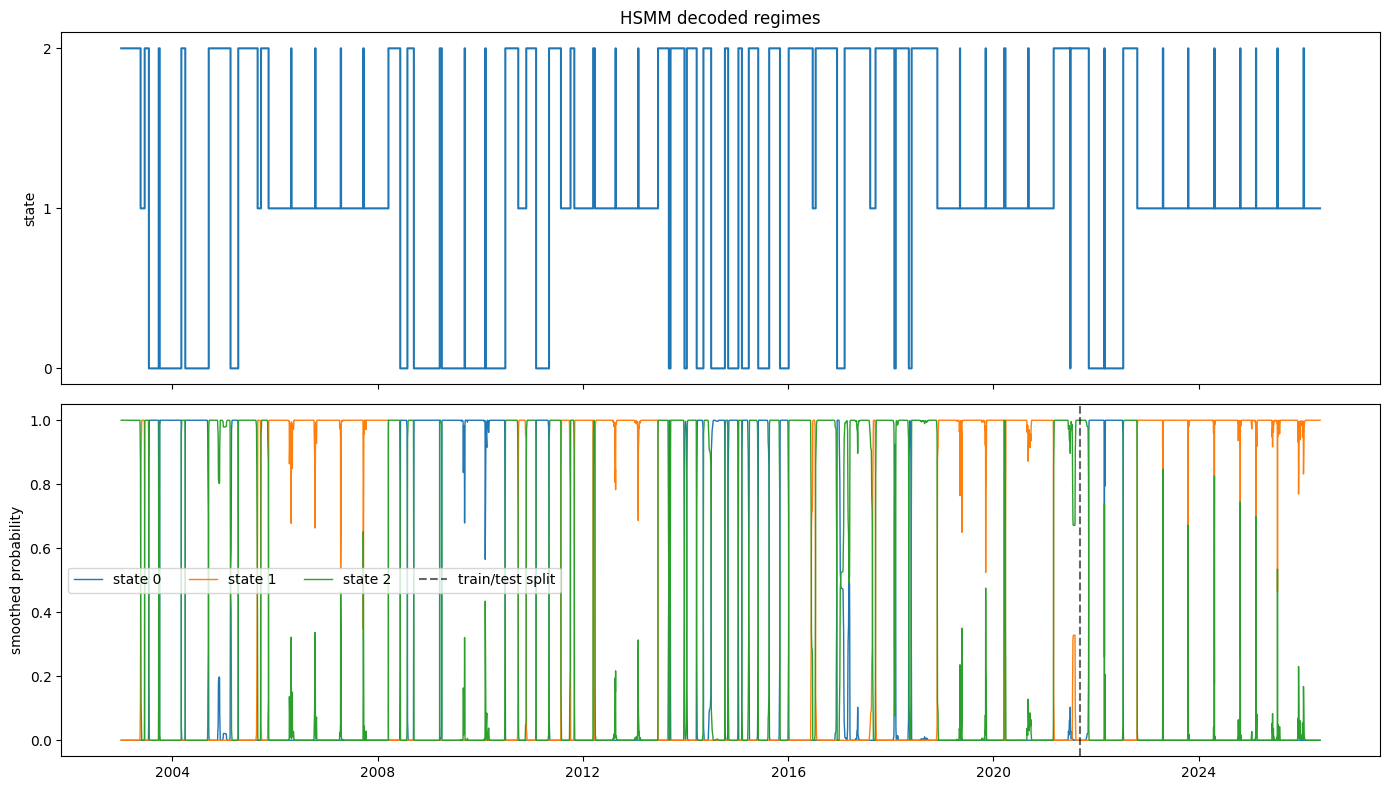

In [5]:
xAll = np.vstack([xTrain, xTest])
states = model.predict(xAll)

results = combined.copy()
results["state"] = states

#one row per consecutive regime spell
spellRows = []
start = 0
for end in range(1, len(states) + 1):
    if end == len(states) or states[end] != states[start]:
        spellRows.append([int(states[start]), results.index[start], results.index[end - 1], end - start])
        start = end
spells = pd.DataFrame(spellRows, columns=["state", "start", "end", "tradingDays"])

print("longest decoded spells:")
print(spells.sort_values("tradingDays", ascending=False).head(10).to_string(index=False))

print("\naverage decoded spell length per state (compare with duration means above):")
print(spells.groupby("state")["tradingDays"].agg(["count", "mean", "max"]).round(1).to_string())

smoothedProbs = model.predict_proba(xAll)
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
axes[0].step(results.index, results["state"], where="post")
axes[0].set_ylabel("state")
axes[0].set_yticks(range(finalStates))
axes[0].set_title("HSMM decoded regimes")
for i in range(finalStates):
    axes[1].plot(results.index, smoothedProbs[:, i], label="state " + str(i), linewidth=1)
axes[1].axvline(testDf.index[0], color="black", linestyle="--", alpha=0.6, label="train/test split")
axes[1].set_ylabel("smoothed probability")
axes[1].legend(ncol=4)
plt.tight_layout()
plt.show()